# Synthetic TDEM Simulation and Inversion
This notebook simulates and inverts synthetic TDEM data for a conductive block in a halfspace.

**Survey Setup:**
- Square transmitter loop on the ground (z=0)
- Receiver line(s) in the air
- Configurable station spacing and line geometry

**Model:**
- Conductive block embedded in a resistive halfspace
- Mesh centered at origin

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from discretize import TreeMesh, TensorMesh
from discretize.utils import ndgrid
from simpeg import (
    maps,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)
from pymatsolver import Pardiso
from simpeg.electromagnetics import time_domain as tdem
from simpeg import data as simpeg_data
import scipy.sparse as sp
from scipy.spatial import cKDTree

### Survey Configuration
Configure the survey geometry here:
- Tx loop size and position
- Rx line geometry (number of lines, line spacing, station spacing)
- Rx flight height

In [3]:
# --- Transmitter Loop Configuration ---
tx_loop_size = 500.0        # Side length of square loop [m]
tx_loop_centre = [0, 0]     # Centre of loop (x, y)
tx_z = 0.0                  # Height of Tx loop (on ground)
tx_n_segments = 1           # Number of segments per side (increase for smoother loop)

# --- Receiver Configuration ---
rx_flight_height = 30.0     # Height above ground [m]

# Option 1: Grid of receivers
rx_type = "grid"            # "grid" or "lines"

# Grid parameters (if rx_type == "grid")
rx_x_min, rx_x_max = -640, 640    # X extent [m]
rx_y_min, rx_y_max = -640, 640    # Y extent [m]
rx_station_spacing_x = 40         # Station spacing in X [m]
rx_station_spacing_y = 40         # Station spacing in Y [m]

# Option 2: Line-based receivers (if rx_type == "lines")
rx_line_direction = "x"           # Lines run in "x" or "y" direction
rx_n_lines = 9                    # Number of receiver lines
rx_line_spacing = 100             # Spacing between lines [m]
rx_station_spacing = 40           # Station spacing along line [m]
rx_line_start = -600              # Start coordinate along line direction
rx_line_end = 600                 # End coordinate along line direction

print("Survey configuration loaded.")

Survey configuration loaded.


In [4]:
def create_square_loop(centre, size, z=0, n_per_side=1):
    """
    Create vertices for a square transmitter loop.
    
    Parameters
    ----------
    centre : (2,) array-like
        (x, y) centre of the loop
    size : float
        Side length of the square
    z : float
        Height of the loop
    n_per_side : int
        Number of points per side (for discretization)
    
    Returns
    -------
    vertices : (N, 3) array
        Loop vertices
    """
    cx, cy = centre
    half = size / 2
    
    # Four corners (counter-clockwise when viewed from above)
    corners = np.array([
        [cx - half, cy - half, z],
        [cx + half, cy - half, z],
        [cx + half, cy + half, z],
        [cx - half, cy + half, z],
    ])
    
    if n_per_side == 1:
        return corners
    
    # Interpolate along each side
    vertices = []
    for i in range(4):
        start = corners[i]
        end = corners[(i + 1) % 4]
        t = np.linspace(0, 1, n_per_side + 1)[:-1]  # exclude endpoint
        seg = start[None, :] + t[:, None] * (end - start)[None, :]
        vertices.append(seg)
    
    return np.vstack(vertices)

tx_locs = create_square_loop(tx_loop_centre, tx_loop_size, tx_z, tx_n_segments)
## add the first vertex at the end to close the loop
tx_locs = np.vstack([tx_locs, tx_locs[0]])
print(f"Tx loop: {tx_locs.shape[0]} vertices, {tx_loop_size}m side length")
tx_locs

Tx loop: 5 vertices, 500.0m side length


array([[-250., -250.,    0.],
       [ 250., -250.,    0.],
       [ 250.,  250.,    0.],
       [-250.,  250.,    0.],
       [-250., -250.,    0.]])

In [5]:
if rx_type == "grid":  
    # Create grid of receivers
    rx_x = np.arange(rx_x_min, rx_x_max + rx_station_spacing_x, rx_station_spacing_x)
    rx_y = np.arange(rx_y_min, rx_y_max + rx_station_spacing_y, rx_station_spacing_y)
    rx_xx, rx_yy = np.meshgrid(rx_x, rx_y)
    rx_locs = np.c_[
        rx_xx.ravel(),
        rx_yy.ravel(),
        rx_flight_height * np.ones(rx_xx.size)
    ]
    
elif rx_type == "lines":
    # Create line-based receivers
    line_coords = np.linspace(
        -rx_line_spacing * (rx_n_lines - 1) / 2,
        rx_line_spacing * (rx_n_lines - 1) / 2,
        rx_n_lines
    )
    station_coords = np.arange(rx_line_start, rx_line_end + rx_station_spacing, rx_station_spacing)
    
    rx_list = []
    for line_pos in line_coords:
        for stn_pos in station_coords:
            if rx_line_direction == "x":
                rx_list.append([stn_pos, line_pos, rx_flight_height])
            else:
                rx_list.append([line_pos, stn_pos, rx_flight_height])
    rx_locs = np.array(rx_list)

n_locations = rx_locs.shape[0]
print(f"Created {n_locations} receiver locations at z = {rx_flight_height} m")

Created 1089 receiver locations at z = 30.0 m


### Time Channels and Waveform
Using the same time channels as the HeliSAM dataset.

In [7]:
# Using same time channels as HeliSAM dataset

time_channels_all = np.array([
    6.8000e-04, 9.2000e-04, 1.1600e-03, 1.4000e-03, 1.6400e-03,
    1.8800e-03, 2.1200e-03, 2.3600e-03, 2.6000e-03, 2.8400e-03,
    3.0800e-03, 3.3200e-03, 3.5600e-03, 3.8000e-03, 4.0400e-03,
    4.2800e-03, 4.5200e-03, 4.7600e-03, 6.2000e-03, 7.6400e-03,
    9.0800e-03, 1.0520e-02, 1.1960e-02, 1.3400e-02, 1.4840e-02,
    1.6280e-02, 1.7720e-02, 1.9160e-02, 2.0600e-02, 2.2040e-02,
    2.3480e-02, 2.4920e-02, 2.6360e-02, 2.7800e-02, 2.9240e-02
])

time_channels = time_channels_all[20:]
n_times_used = len(time_channels)

print(f"Using {n_times_used} time channels")
print(f"Time range: {time_channels[0]*1e3:.3f} - {time_channels[-1]*1e3:.3f} ms")

Using 15 time channels
Time range: 9.080 - 29.240 ms


In [8]:
min_diff_dist = 1250 * np.sqrt(time_channels.max() / 1e-3)
print("Background max DIFFUSION DISTANCE: {} m".format(min_diff_dist))
max_diff_dist = 1250 * np.sqrt(time_channels.min() / 1.0)
print("Fold min DIFFUSION DISTANCE: {} m".format(max_diff_dist))

Background max DIFFUSION DISTANCE: 6759.252917297887 m
Fold min DIFFUSION DISTANCE: 119.11129249571596 m


In [9]:
waveform = tdem.sources.StepOffWaveform()


### Mesh Design
Create a TreeMesh centered at the origin.

In [ ]:
min_cell_size = 50.0          # Minimum cell size 
min_cell_size_z = 50.0        # Minimum cell size in z

# Core region (region of interest)
core_x = np.r_[-500, 500]
core_y = np.r_[-500, 500]
core_z = np.r_[0, -500]       # Surface to depth

# Padding distance
pad_dist = 30000
pad_dist_z = 30000

print(f"Core region: X=[{core_x[0]}, {core_x[1]}], Y=[{core_y[0]}, {core_y[1]}], Z=[{core_z[1]}, {core_z[0]}]")

Core region: X=[-500, 500], Y=[-500, 500], Z=[-500, 0]


In [11]:
num_base_cells = 2 ** int(np.round(np.log(pad_dist / min_cell_size) / np.log(2.0)))
num_base_cells_z = 2 ** int(np.round(np.log(pad_dist_z / min_cell_size_z) / np.log(2.0)))

h = [(min_cell_size, num_base_cells)]
hz = [(min_cell_size_z, num_base_cells_z)]

mesh = TreeMesh([h, h, hz], origin="CCC", diagonal_balance=True)
# Centre mesh at origin with top at z=0
mesh.origin = np.r_[0, 0, core_z[0]] - np.array([mesh.h[0].sum()/2, mesh.h[1].sum()/2, mesh.h[2].sum()/2])
mesh.origin[2] = -mesh.h[2].sum()/2  # Top of mesh at z=0 (approximately)

# Refine around Tx loop
mesh.refine_points(tx_locs, level=-1, padding_cells_by_level=[4, 4, 2], finalize=False)

# Refine in core region
core_grid = ndgrid(core_x, core_y, core_z)
mesh.refine_bounding_box(core_grid, level=-1, padding_cells_by_level=[4, 4, 4, 2], finalize=False)

mesh.finalize()
print(mesh)


OcTreeMesh: 0.03% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  3   :       448            ---------------------------   --------------------
  4   :       332         x:   -12800.0   ,   12800.0         50.0   ,   3200.0  
  5   :       992         y:   -12800.0   ,   12800.0         50.0   ,   3200.0  
  6   :      2684         z:   -12800.0   ,   12800.0         50.0   ,   3200.0  
  7   :      5760      
  8   :      8704      
  9   :      22528     
-----------------------
Total :      41448     


### Synthetic Model
Create a conductive block in a resistive halfspace.

In [12]:
background_cond = 1e-3
block_cond = 1.0

# Block geometry (centred at origin, below surface)
block_x = [-200, 200]   # X extent [m]
block_y = [-200, 200]   # Y extent [m]
block_z = [-50, -200]  # Z extent [m] (top to bottom)

air_cond = 1e-8  # S/m

print(f"Background conductivity: {background_cond} S/m ({1/background_cond:.0f} Ohm-m)")
print(f"Block conductivity: {block_cond} S/m ({1/block_cond:.0f} Ohm-m)")
print(f"Block location: X=[{block_x[0]}, {block_x[1]}], Y=[{block_y[0]}, {block_y[1]}], Z=[{block_z[0]}, {block_z[1]}]")

Background conductivity: 0.001 S/m (1000 Ohm-m)
Block conductivity: 1.0 S/m (1 Ohm-m)
Block location: X=[-200, 200], Y=[-200, 200], Z=[-50, -200]


In [13]:
active_cells = mesh.cell_centers[:, 2] < 0
n_active = np.sum(active_cells)
print(f"Number of active cells: {n_active}")

sigma_true = air_cond * np.ones(mesh.n_cells)
sigma_true[active_cells] = background_cond
sigma_halfspace = sigma_true.copy()  # Save halfspace model for later
cc = mesh.cell_centers
block_inds = (
    (cc[:, 0] >= block_x[0]) & (cc[:, 0] <= block_x[1]) &
    (cc[:, 1] >= block_y[0]) & (cc[:, 1] <= block_y[1]) &
    (cc[:, 2] >= block_z[1]) & (cc[:, 2] <= block_z[0])  # Note: z is negative
)

sigma_true[block_inds] = block_cond

print(f"Block contains {np.sum(block_inds)} cells")

Number of active cells: 26912
Block contains 192 cells


### Mappings


In [15]:
exp_map = maps.ExpMap(mesh)
active_map = maps.InjectActiveCells(mesh, active_cells, np.log(air_cond))

# Simulation mapping: log(sigma) -> sigma
simulation_map = exp_map * active_map

print(f"Model size: {n_active} active cells")

Model size: 26912 active cells


### RBF Level Set Setup

In [16]:

def random_rbf_centres_on_mesh(
    mesh,
    n_rbf_target: int,
    min_dist: float,
    *,
    active_mask=None,                    # optional: restrict to active cells
    region_bounds=None,                  # optional: ((xmin,xmax),(ymin,ymax),(zmin,zmax))
    seed: int | None = 1234,
    verbose: bool = True,
):
    """
    Randomly select cell-centre locations with a hard minimum separation.
    Greedy selection over a KDTree built on the candidate pool.
    RBF centres are restricted to mesh cell centers only.
    """
    rng = np.random.default_rng(seed)
    cc = mesh.cell_centers  # (nC,3)

    # candidate mask
    mask = np.ones(cc.shape[0], dtype=bool)
    if active_mask is not None:
        mask &= np.asarray(active_mask, dtype=bool).ravel(order="F")
    if region_bounds is not None:
        (xb, yb, zb) = region_bounds
        mask &= (cc[:, 0] >= xb[0]) & (cc[:, 0] <= xb[1])
        mask &= (cc[:, 1] >= yb[0]) & (cc[:, 1] <= yb[1])
        mask &= (cc[:, 2] >= zb[0]) & (cc[:, 2] <= zb[1])

    # Get candidate cell center indices (not coordinates)
    candidate_indices = np.where(mask)[0]
    pool = cc[candidate_indices]  # coordinates of candidate cell centers
    
    if pool.size == 0:
        raise ValueError("No candidate cells after masking; relax bounds or masks.")

    # KDTree on pool (fixed)
    tree = cKDTree(pool)

    order = rng.permutation(pool.shape[0])
    valid = np.ones(pool.shape[0], dtype=bool)
    chosen_local_indices = []

    # Greedy: when a point is chosen, invalidate all neighbours within min_dist
    for idx in order:
        if not valid[idx]:
            continue
        chosen_local_indices.append(idx)
        if len(chosen_local_indices) >= n_rbf_target:
            break
        nbrs = tree.query_ball_point(pool[idx], r=float(min_dist) - 1e-9)
        valid[nbrs] = False  # includes self

    # Map back to cell center coordinates
    rbf_centres = pool[np.asarray(chosen_local_indices)]
    
    if verbose:
        if len(rbf_centres) < n_rbf_target:
            print(f"[random_rbf_centres_on_mesh] Requested {n_rbf_target}, "
                  f"placed {len(rbf_centres)} with min_dist={min_dist} m. "
                  f"Consider reducing min_dist or restricting region.")
        else:
            print(f"[random_rbf_centres_on_mesh] Placed {len(rbf_centres)} centres.")

    return rbf_centres

rbf_spacing = 100

n_rbf_target   = 10000          
min_separation = rbf_spacing         
seed           = 42

region = None

rbf_centres = random_rbf_centres_on_mesh(
    mesh,
    n_rbf_target,
    min_separation,
    active_mask=active_cells,     # keep centres off air cells
    region_bounds=region,
    seed=seed,
    verbose=True,
)
n_rbf = rbf_centres.shape[0]
full_rbf_spacing = np.full(n_rbf, float(rbf_spacing))
print("Num RBFs:", n_rbf)

[random_rbf_centres_on_mesh] Placed 10000 centres.
Num RBFs: 10000


In [17]:
def _sigma(alpha):
    return np.arctan(alpha * 0.5)

def _sigma_prime(alpha):
    return 2.0 / (4.0 + alpha * alpha)


def rbf_kernel(params, xyz, m, return_deriv=False, jvec=None, normalize_C=False,
               _cache={}):
    """
    Gaussian RBF level-set kernel.

    params : [centres (N,3), eps, w_1, ..., w_N]
    xyz    : (M, 3) mesh cell centres (active only)
    m      : (N+2,) parameter vector [alpha_1..N, c_low, c_high]

    Returns density = c_high + (c_low - c_high) * H(phi)

    The sparse Psi matrix and its derived index arrays are built once on the
    first call and reused on subsequent calls (geometry is fixed across
    iterations). Pass _cache={} to force a rebuild.
    """
    centres = np.asarray(params[0])
    N = centres.shape[0]
    eps = float(params[1])
    widths = np.asarray(params[2 : 2 + N])

    if "psi" not in _cache:
        tree_xyz = cKDTree(xyz)
        w_unique, w_inv = np.unique(widths, return_inverse=True)
        rows, cols, vals = [], [], []
        threshold = 1e-8

        for gi, w in enumerate(w_unique):
            idx = np.where(w_inv == gi)[0]
            if idx.size == 0:
                continue
            r_max = float(w) * np.sqrt(-np.log(threshold))
            dist = tree_xyz.sparse_distance_matrix(
                cKDTree(centres[idx]), r_max, output_type="coo_matrix",
            )
            if dist.nnz == 0:
                continue
            v = np.exp(-(dist.data / float(w)) ** 2)
            keep = v > threshold
            rows.append(dist.row[keep])
            cols.append(idx[dist.col[keep]])
            vals.append(v[keep])

        if vals:
            psi = sp.csr_matrix(
                (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
                shape=(xyz.shape[0], N),
            )
            psi.sum_duplicates()
        else:
            psi = sp.csr_matrix((xyz.shape[0], N))

        row_sum = np.asarray(psi.sum(axis=1)).ravel()
        _cache["psi"] = psi
        _cache["inv_row"] = 1.0 / (row_sum + 1e-12)
        _cache["row_idx"] = np.repeat(np.arange(psi.shape[0]), np.diff(psi.indptr))

    psi = _cache["psi"]
    inv_row = _cache["inv_row"]
    row_idx = _cache["row_idx"]

    alpha = np.asarray(m[:N])
    c_low, c_high = float(m[N]), float(m[N + 1])
    contrast = c_high - c_low

    phi = psi @ _sigma(alpha)
    if normalize_C:
        phi *= inv_row

    arg = (np.pi / eps) * phi
    T = 0.5 + (1.0 / np.pi) * np.arctan(arg)

    if not return_deriv and jvec is None:
        return c_low + contrast * T

    # Jacobian w.r.t. [alpha, c_low, c_high]
    T_prime = 1.0 / (eps * (1.0 + arg * arg))
    scale = contrast * T_prime
    if normalize_C:
        scale *= inv_row

    J_alpha = psi.copy()
    J_alpha.data *= _sigma_prime(alpha)[J_alpha.indices]
    J_alpha.data *= scale[row_idx]

    J_chigh = sp.csr_matrix(T.reshape(-1, 1))
    J_clow = sp.csr_matrix((1.0 - T).reshape(-1, 1))

    return sp.hstack([J_alpha, J_clow, J_chigh], format="csr")

In [111]:
## Initialize the model by activating the RBFs within X metres of the centre
centre = np.array([0, 0, -100])  
distances = np.sqrt(np.sum((rbf_centres - centre)**2, axis=1))
indices_within_Xm = np.where(distances <= 100)[0]

alpha_init =  -1* np.ones(n_rbf)
alpha_init[indices_within_Xm] = 10.0

c_low_fixed = np.log(1e-3)
c_high_fixed = np.log(1e2)

param_model = np.r_[alpha_init, c_low_fixed, c_high_fixed]
eps_init = 0.1
# Define extra fixed parameters (not being inverted for)
extra_params = [rbf_centres, eps_init, *full_rbf_spacing]
num_params = len(param_model)

torch_map = maps.ParametricRBFMapping(mesh=mesh,nP=num_params,active_cells=active_cells,
                                       params=extra_params,forward_transform=rbf_kernel)
param_map = exp_map * active_map * torch_map


### Define Survey Object

In [113]:
## Lalor incl and decl
inclination_deg = 78.0
declination_deg = 5.2
I = np.radians(inclination_deg)
D = np.radians(declination_deg)

# direction cosines, [x_east, y_north, z_up-positive]
bhat_x = np.cos(I) * np.sin(D)
bhat_y = np.cos(I) * np.cos(D)
bhat_z = -np.sin(I)
field_direction = np.array([bhat_x, bhat_y, bhat_z])

print(f'b_hat_earth = {field_direction}    (|b_hat| = {np.linalg.norm(field_direction):.4f})')


rx_list = [
    tdem.receivers.PointMagneticFluxDensity(
        locations=rx_locs,
        times=time_channels,
        orientation=field_direction
    )
]

src_list = tdem.sources.LineCurrent(
    receiver_list=rx_list,
    location=tx_locs,
)

source_list = [src_list]
survey = tdem.Survey(source_list)

print(f"Survey created with {survey.nD} data points")
print(f"  = {n_locations} locations × {n_times_used} time channels")

b_hat_earth = [ 0.01884357  0.20705601 -0.9781476 ]    (|b_hat| = 1.0000)
Survey created with 16335 data points
  = 1089 locations × 15 time channels


### Time Stepping

In [114]:
min_time_step = time_channels_all[0] / 30
print(f'Minimum time step: {min_time_step*1e6:.2f} µs')

time_steps = [
    (min_time_step, 20),              # Early time
    (3 * min_time_step, 20),          # Mid time
    (9 * min_time_step, 20),          # Late time
    (36 * min_time_step, 30),         # Very late time
]

total_time = sum([dt * n for dt, n in time_steps])
print(f"Total simulation time: {total_time*1e3:.2f} ms")
print(f"Latest time channel: {time_channels[-1]*1e3:.2f} ms")

Minimum time step: 22.67 µs
Total simulation time: 30.37 ms
Latest time channel: 29.24 ms


### Forward Simulation

In [115]:
sim_nonparam = tdem.Simulation3DMagneticFluxDensity(
    mesh=mesh,
    survey=survey,
    sigmaMap=simulation_map,
    solver=Pardiso,
)

sim_param = tdem.Simulation3DMagneticFluxDensity(
    mesh=mesh,
    survey=survey,
    sigmaMap=param_map,
    solver=Pardiso,
)

# select whether to use parametric or non-parametric sim
sim = sim_param

sim.time_steps = time_steps
sim_nonparam.time_steps = time_steps
print(f"Simulation created with {sim.nT} time steps")

Simulation created with 90 time steps


In [ ]:
log_sigma_true = np.log(sigma_true)
log_sigma_halfspace = np.log(sigma_halfspace)
print("Running forward simulation...")
dpred_true = sim_nonparam.dpred(log_sigma_true[active_cells])
print(f"Forward simulation complete. Data shape: {dpred_true.shape}")
dpred_halfspace = sim_nonparam.dpred(log_sigma_halfspace[active_cells])

In [80]:
relative_error = 0.01      # 1% relative error
noise_floor = 1e-12       # Absolute noise floor [T]

std = np.sqrt((relative_error * np.abs(dpred_true))**2)

np.random.seed(42)  
noise = np.random.randn(dpred_true.size) * std
dobs = dpred_true + noise

print(f"Data range: {dobs.min():.2e} to {dobs.max():.2e} T")
print(f"Noise floor: {noise_floor:.2e} T")

Data range: -1.37e-10 to 8.58e-12 T
Noise floor: 1.00e-12 T


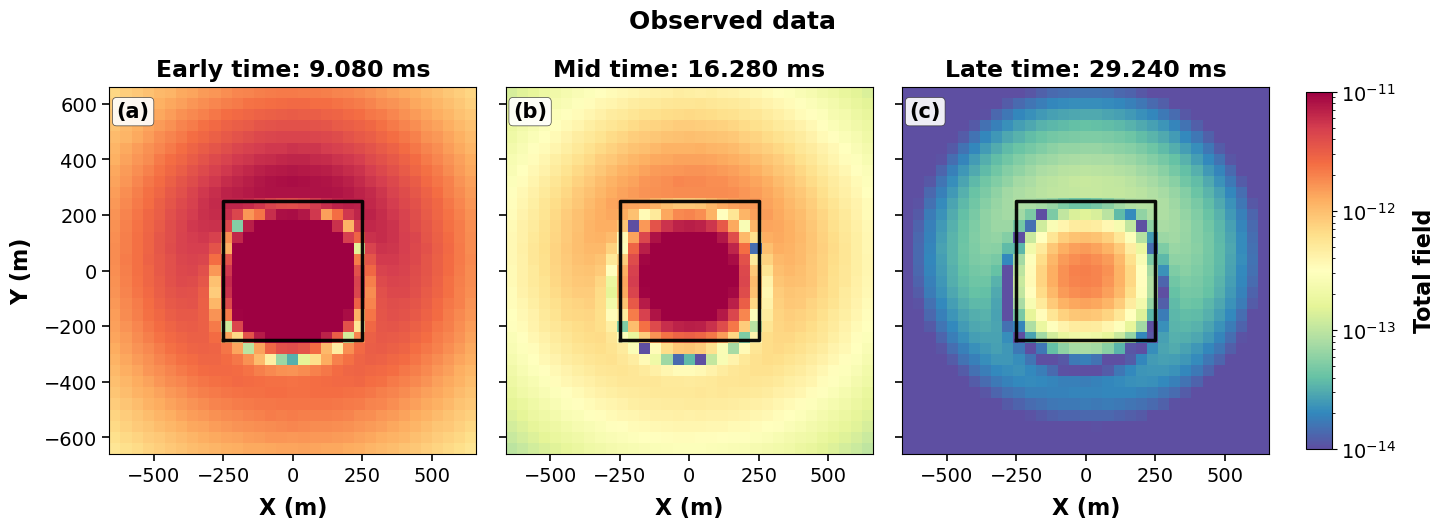

In [ ]:
panel_font  = dict(fontsize=15, fontweight="bold")
title_font  = dict(fontsize=17, fontweight="bold", pad=10)
label_font  = dict(fontsize=16, fontweight="bold")
tick_kw     = dict(labelsize=14, width=1.2, length=5)
bbox_kw     = dict(boxstyle="round,pad=0.18", fc="white", ec="0.2", lw=0.4, alpha=0.9)


def _centers_to_edges(vals):
    vals = np.asarray(vals, dtype=float)
    if vals.size == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5], dtype=float)
    dv = np.diff(vals)
    edges = np.empty(vals.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (vals[:-1] + vals[1:])
    edges[0] = vals[0] - 0.5 * dv[0]
    edges[-1] = vals[-1] + 0.5 * dv[-1]
    return edges


def _overlay_receivers(ax, rx_locs, *, color='black', size=10, alpha=0.34):
    ax.scatter(
        rx_locs[:, 0],
        rx_locs[:, 1],
        s=size,
        c=color,
        edgecolors="white",
        linewidths=0.5,
        alpha=alpha,
        zorder=7,
    )


def _panel_tag(ax, label):
    ax.text(
        0.02,
        0.96,
        label,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=panel_font["fontsize"],
        fontweight=panel_font["fontweight"],
        color="k",
        bbox=bbox_kw,
    )


def _style_panel(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, fontsize=title_font["fontsize"], fontweight=title_font["fontweight"], pad=title_font["pad"])
    if xlabel is None:
        ax.set_xlabel("")
    else:
        ax.set_xlabel(xlabel, fontsize=label_font["fontsize"], fontweight=label_font["fontweight"], labelpad=4)
    if ylabel is None:
        ax.set_ylabel("")
    else:
        ax.set_ylabel(ylabel, fontsize=label_font["fontsize"], fontweight=label_font["fontweight"], labelpad=4)
    ax.tick_params(axis="both", **tick_kw)
    ax.grid(False)
    ax.set_facecolor("white")


def plot_dobs_thesis_1x3(
    dat,
    time_indices=(0, 10, -1),
    *,
    n_locations=n_locations,
    n_times=n_times_used,
    rx_locs=rx_locs,
    tx_locs=tx_locs,
    time_channels=time_channels,
    cmap="Spectral_r",
    vmin=1e-14,
    vmax=1e-11,
    colorbar_label="Total field",
    title_prefix=None,
):
    from matplotlib.ticker import LogFormatterMathtext, LogLocator

    arr = np.asarray(dat).reshape((n_locations, n_times), order="F")
    x_unique = np.unique(rx_locs[:, 0])
    y_unique = np.unique(rx_locs[:, 1])
    if x_unique.size * y_unique.size != n_locations:
        raise ValueError("Rx locations are not a full X-Y grid; gridded plotting requires a complete grid.")

    x_idx = np.searchsorted(x_unique, rx_locs[:, 0])
    y_idx = np.searchsorted(y_unique, rx_locs[:, 1])
    x_edges = _centers_to_edges(x_unique)
    y_edges = _centers_to_edges(y_unique)

    data_norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(1, 3, figsize=(18.2, 5.8))
    fig.subplots_adjust(left=0.055, right=0.875, bottom=0.14, top=0.88, wspace=0.14)

    tx_x = np.append(tx_locs[:, 0], tx_locs[0, 0])
    tx_y = np.append(tx_locs[:, 1], tx_locs[0, 1])
    panel_labels = ["(a)", "(b)", "(c)"]
    stage = ["Early time", "Mid time", "Late time"]
    last_pcm = None

    for i, idx in enumerate(time_indices):
        ax = axes[i]
        z = np.abs(arr[:, idx])
        z = np.clip(z, vmin, None)
        z_grid = np.full((y_unique.size, x_unique.size), np.nan, dtype=float)
        z_grid[y_idx, x_idx] = z

        last_pcm = ax.pcolormesh(
            x_edges,
            y_edges,
            z_grid,
            cmap=cmap,
            norm=data_norm,
            shading="auto",
        )
        ax.plot(tx_x, tx_y, color="k", linewidth=2.0, alpha=0.9, zorder=6)
        _overlay_receivers(ax, rx_locs)

        t_ms = time_channels[idx] * 1e3
        _style_panel(ax, f"{stage[i]}: {t_ms:.3f} ms", "X (m)", "Y (m)" if i == 0 else None)
        ax.set_aspect("equal", adjustable="box")
        ax.set_box_aspect(1)
        _panel_tag(ax, panel_labels[i])

    if title_prefix is not None:
        fig.suptitle(
            title_prefix,
            y=0.98,
            fontsize=title_font["fontsize"],
            fontweight=title_font["fontweight"],
        )

    cbar_ax = fig.add_axes([0.895, 0.14, 0.018, 0.68])
    cbar = fig.colorbar(last_pcm, cax=cbar_ax)
    cbar.set_label(
        colorbar_label,
        fontsize=label_font["fontsize"],
        fontweight=label_font["fontweight"],
        labelpad=10,
    )
    cbar.locator = LogLocator(base=10.0)
    cbar.formatter = LogFormatterMathtext(base=10.0)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=14)

    plt.show()
    return fig, axes


fig_data, axes_data = plot_dobs_thesis_1x3(dobs, time_indices=(0, 5, -1))

### Inversion Setup

In [33]:
uncertainty = 0.05 * np.abs(dobs) + noise_floor

data_obj = simpeg_data.Data(
    survey=survey,
    dobs=dobs,
    standard_deviation=uncertainty
)
print(f"Uncertainty range: {uncertainty.min():.2e} to {uncertainty.max():.2e}")

print(f"Data object created with {data_obj.nD} data points")

Uncertainty range: 1.00e-12 to 7.87e-12
Data object created with 16335 data points


In [95]:
lower_bound = np.log(5e-4)   
upper_bound = np.log(1e1) 

lower_bounds_l2 = lower_bound * np.ones(n_active)
upper_bounds_l2 = upper_bound * np.ones(n_active)

# Starting model (homogeneous halfspace)
m0 = np.log(background_cond) * np.ones(n_active)

print(f"Starting model: log {background_cond} S/m")

m0_param = param_model.copy()
alpha_lower_bound = -10.0   
alpha_upper_bound = 10.0
c_low_bound_lower = np.log(1e-4)
c_low_bound_upper = np.log(1e-2)  
c_high_bound_lower = np.log(1e-1)
c_high_bound_upper = np.log(1e2)
lower_bounds = np.r_[
    alpha_lower_bound * np.ones(n_rbf),
    c_low_bound_lower, 
    c_high_bound_lower
]

upper_bounds = np.r_[
    alpha_upper_bound * np.ones(n_rbf),
    c_low_bound_upper,
    c_high_bound_upper 
]

Starting model: log 0.001 S/m


## RBF Level-Set Inversion

In [ ]:
dmisfit = data_misfit.L2DataMisfit(simulation=sim, data=data_obj)

reg = regularization.WeightedLeastSquares(
    mesh=TensorMesh([np.ones(num_params)]),
)

opt = optimization.ProjectedGNCG(
    maxIter=30,          
    maxIterLS=50,
    maxIterCG=50,        
    lower=lower_bounds,
    upper=upper_bounds
)

inv_prob = inverse_problem.BaseInvProblem(dmisfit, reg, opt, beta=1e2)

sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)

beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1e0, n_pw_iter=1)
beta_cooling = directives.BetaSchedule(coolingFactor=2, coolingRate=2)
target = directives.TargetMisfit(chifact=1)
save_model = directives.SaveModelEveryIteration(directory="results/helisam_syn_5pct/")
save_output = directives.SaveOutputEveryIteration(directory="results/helisam_syn_5pct/", save_txt=True)

directive_list = [ beta_cooling, save_model, save_output, target]

inv = inversion.BaseInversion(inv_prob, directiveList=directive_list)

print("Inversion setup complete.")

Inversion setup complete.


/tmp/ipykernel_125822/2690769973.py:23: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  opt = optimization.ProjectedGNCG(
/home/ppokar/miniconda/envs/parametric_2026/lib/python3.11/site-packages/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val
/home/ppokar/miniconda/envs/parametric_2026/lib/python3.11/site-packages/simpeg/directives/_directives.py:1865: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.save_txt = save_txt
/home/ppokar/miniconda/envs/parametric_2026/lib/python3.11/site-packages/simpeg/directives/_directives.py:1866: FutureWarning: SaveEveryIteration.save_txt has been deprecated, please use SaveEveryIter

In [118]:
mrec = inv.run(m0_param)
print("Inversion complete.")

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation3DMagneticFluxDensity simulation with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 16335.0



Running inversion with SimPEG v0.25.2
SaveModelEveryIteration will save your models as: '/t40array/ppokar/parametric/thesis/helisam_syn_5pct/InversionModel_2026-05-31-13-16_00.npy'
'SaveOutputEveryIteration' will save your inversion progress to: '/t40array/ppokar/parametric/thesis/helisam_syn_5pct/InversionModel_2026-05-31-13-16.txt'
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.00e+02  8.17e+04  3.83e+02  1.20e+05                         0           inf          inf                
Linesearch failed. Stepping anyways...
   1  1.00e+02  8.17e+04  3.83e+02  1.20e+05    1.12e+02     50      50       1.06e+02     1.01e+06              


/home/ppokar/miniconda/envs/parametric_2026/lib/python3.11/site-packages/simpeg/directives/_directives.py:1938: UserWarning: File /t40array/ppokar/parametric/thesis/helisam_syn_5pct/InversionModel_2026-05-31-13-16.txt was not found, creating a new one.
  self._mkdir_and_check_output_file(should_exist=True)


   2  1.00e+02  8.17e+04  3.83e+02  1.20e+05    1.12e+02     18      50       1.06e+02     1.01e+06              
   3  5.00e+01  7.46e+04  3.60e+02  9.26e+04    1.12e+02      3      50       1.76e+01     1.62e+05   Skip BFGS  
   4  5.00e+01  3.51e+04  3.00e+02  5.01e+04    1.40e+02      1      17       8.48e-09     4.77e-04              
   5  2.50e+01  1.27e+04  3.18e+02  2.06e+04    1.16e+02      1      46       9.59e-09     9.04e-04              
------------------------- STOP! -------------------------
0 : |fc-fOld| = 2.1968e+04 <= tolF*(1+|f0|) = 1.2006e+04
1 : |xc-x_last| = 4.3174e+00 <= tolX*(1+|x0|) = 1.0170e+01
0 : |proj(x-g)-x|    = 1.1642e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 1.1642e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      30    <= iter          =      5
------------------------- DONE! -------------------------
Inversion complete.


### L2 Inversion

In [ ]:
dmisfit = data_misfit.L2DataMisfit(simulation=sim_nonparam, data=data_obj)

reg = regularization.WeightedLeastSquares(
    mesh=mesh,
    active_cells=active_cells,
)

opt = optimization.ProjectedGNCG(
    maxIter=30,          
    maxIterLS=50,
    maxIterCG=50,        
    lower=lower_bounds_l2,
    upper=upper_bounds_l2
)

inv_prob = inverse_problem.BaseInvProblem(dmisfit, reg, opt,)

beta_est = directives.BetaEstimate_ByEig(beta0_ratio=1e2, n_pw_iter=1)
beta_cooling = directives.BetaSchedule(coolingFactor=2, coolingRate=2)
target = directives.TargetMisfit(chifact=1)
save_model = directives.SaveModelEveryIteration(directory="results/helisam_syn_l2/")
save_output = directives.SaveOutputEveryIteration(directory="results/helisam_syn_l2/", save_txt=True)
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)

directive_list = [beta_cooling, save_model, save_output, target]

inv = inversion.BaseInversion(inv_prob, directiveList=directive_list)

print("Inversion setup complete.")

In [ ]:
#mrec_l2 = inv.run(m0)

### Inversion Results

In [ ]:
# loaded result overrides the live L2 run above
mrec_l2 = np.load("results/helisam_syn_l2_5pct_halfspace/InversionModel_2026-05-31-10-00_21.npy")
mrec_rbf = mrec

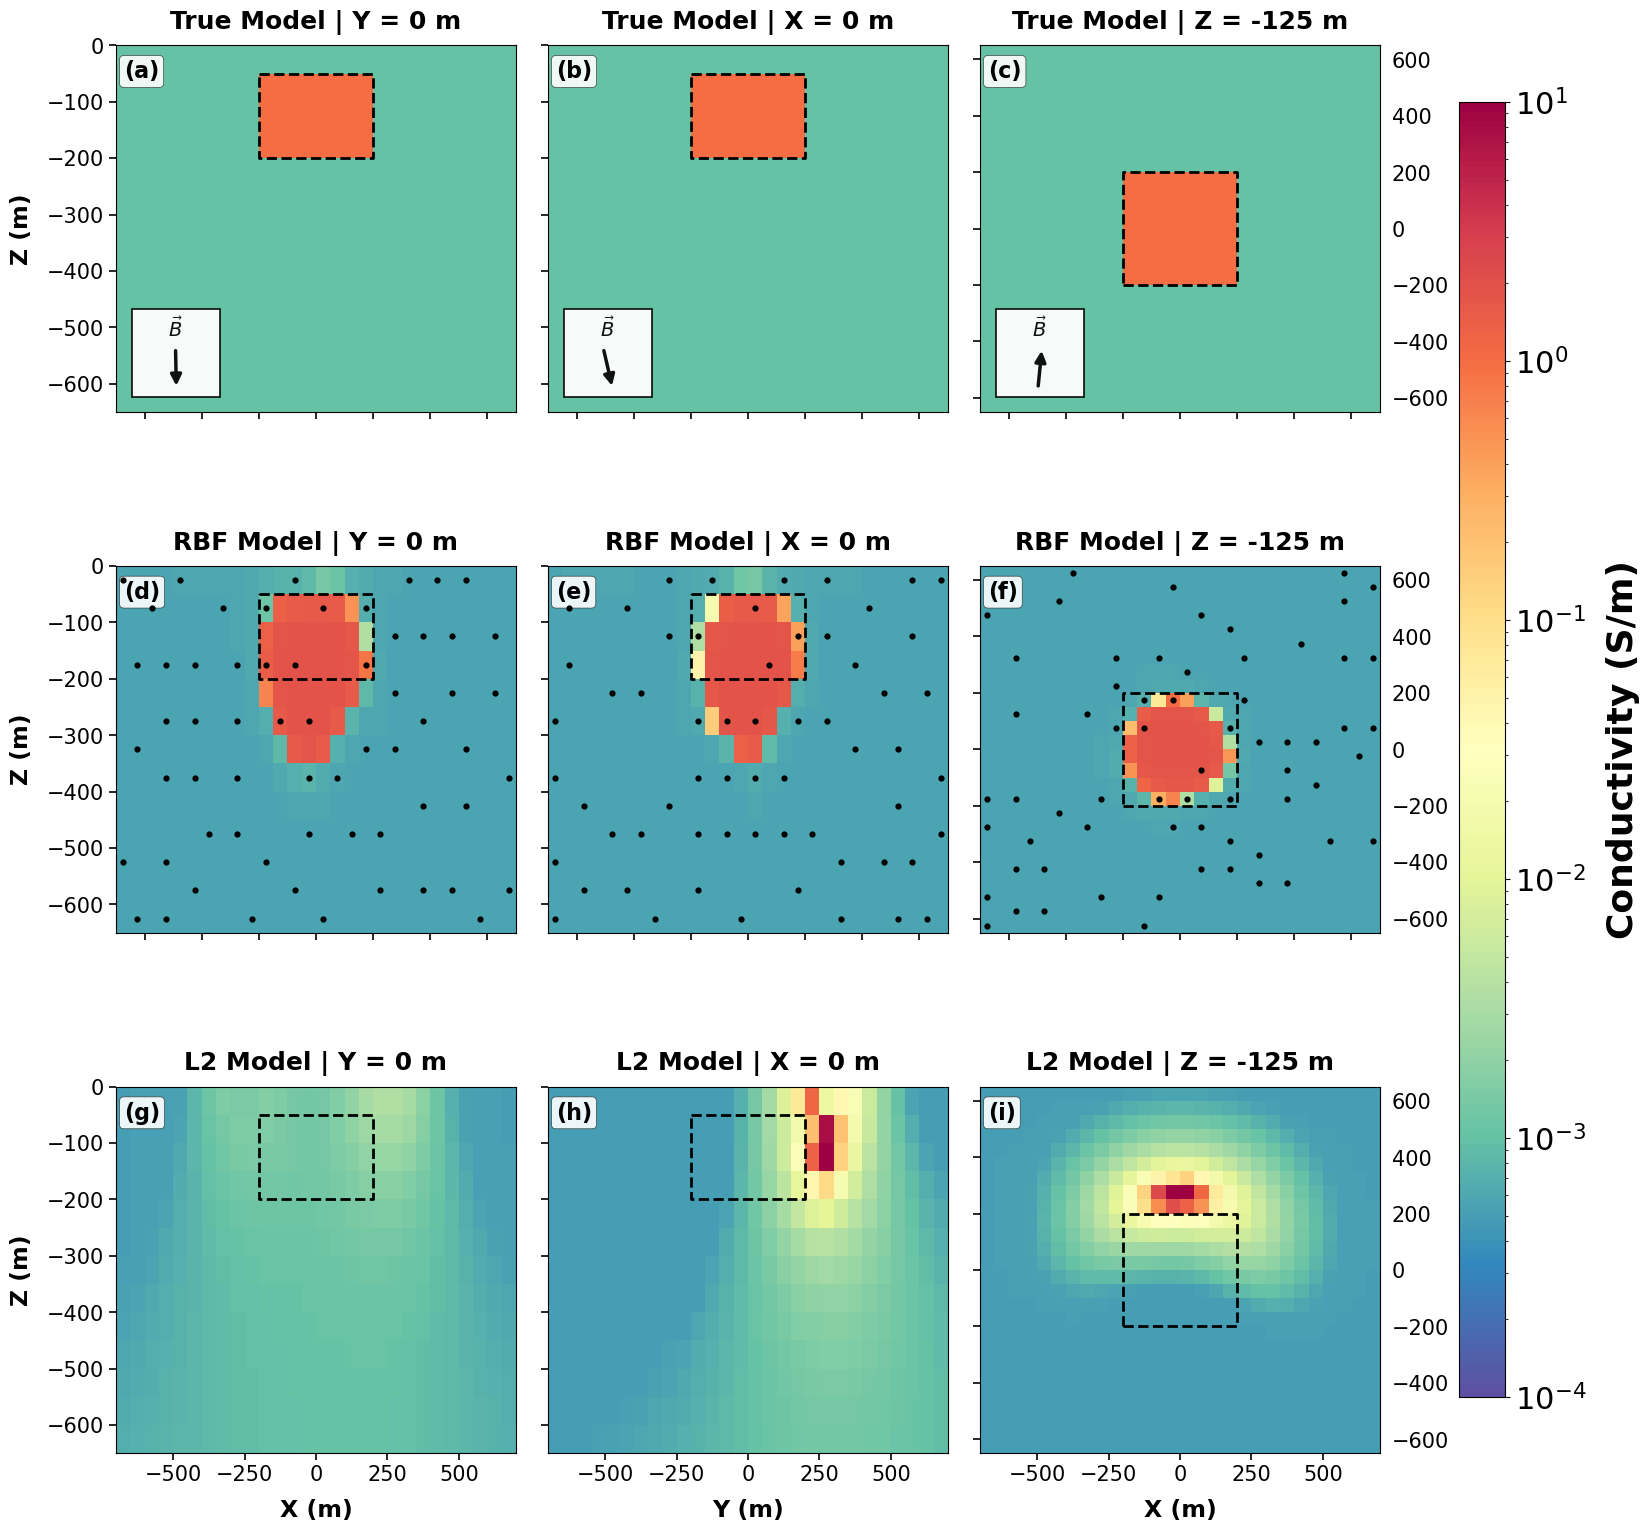

In [167]:
sigma_true_plot = simulation_map * log_sigma_true[active_cells]
sigma_rbf_plot = param_map * mrec_rbf
sigma_l2_plot = simulation_map * mrec_l2

fig, axes = plt.subplots(3, 3, figsize=(20, 16), constrained_layout=False)
norm = LogNorm(vmin=1e-4, vmax=1e1)
sm = plt.cm.ScalarMappable(norm=norm, cmap="Spectral_r")

models = [
    ("True Model", sigma_true_plot),
    ("RBF Model", sigma_rbf_plot),
    ("L2 Model", sigma_l2_plot),
]

slice_specs = [
    ("Y", int(mesh.shape_cells[1] / 2), "Y = 0 m", (-700, 700), (-650, 0), "X (m)", "Z (m)"),
    ("X", int(mesh.shape_cells[0] / 2), "X = 0 m", (-700, 700), (-650, 0), "Y (m)", "Z (m)"),
    ("Z", np.argmin(np.abs(mesh.cell_centers_z - (block_z[0] + block_z[1]) / 2)), f"Z = {(block_z[0] + block_z[1]) / 2:.0f} m", (-700, 700), (-650, 650), "X (m)", "Y (m)"),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]
rbf_slice_tol = 0.5 * min_cell_size


from matplotlib.patches import Rectangle


def _add_b_arrow(ax, normal):
    direction = np.array([bhat_x, bhat_y, bhat_z], dtype=float)
    if normal == "Y":
        proj = np.array([direction[0], direction[2]], dtype=float)
    elif normal == "X":
        proj = np.array([direction[1], direction[2]], dtype=float)
    else:
        proj = np.array([direction[0], direction[1]], dtype=float)

    norm_proj = np.linalg.norm(proj)
    if norm_proj == 0:
        return
    proj /= norm_proj

    box_x0, box_y0, box_w, box_h = 0.04, 0.04, 0.22, 0.24
    ax.add_patch(
        Rectangle(
            (box_x0, box_y0),
            box_w,
            box_h,
            transform=ax.transAxes,
            facecolor="white",
            edgecolor="black",
            linewidth=1.2,
            alpha=0.95,
            zorder=7,
        )
    )

    ax.text(
        box_x0 + box_w / 2,
        box_y0 + 0.78 * box_h,
        r"$\vec{B}$",
        transform=ax.transAxes,
        fontsize=14,
        color="#111111",
        ha="center",
        va="center",
        zorder=9,
    )

    margin = 0.15 * box_w
    ax0, ax1 = box_x0 + margin, box_x0 + box_w - margin
    ay0, ay1 = box_y0 + 0.08 * box_h, box_y0 + 0.58 * box_h
    cx, cy = (ax0 + ax1) / 2, (ay0 + ay1) / 2

    max_len = np.inf
    if abs(proj[0]) > 1e-12:
        max_len = min(max_len, ((ax1 - cx) if proj[0] > 0 else (cx - ax0)) / abs(proj[0]))
    if abs(proj[1]) > 1e-12:
        max_len = min(max_len, ((ay1 - cy) if proj[1] > 0 else (cy - ay0)) / abs(proj[1]))

    scale = 0.80 * max_len
    start = np.array([cx - scale * proj[0], cy - scale * proj[1]])
    end   = np.array([cx + scale * proj[0], cy + scale * proj[1]])

    ax.annotate(
        "",
        xy=end, xytext=start,
        xycoords=ax.transAxes, textcoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="-|>", color="#111111",
            lw=2.5, mutation_scale=16,
            shrinkA=0, shrinkB=0,
        ),
        zorder=8,
    )


for row, (model_name, model_values) in enumerate(models):
    for col, (normal, ind, slice_title, xlim, ylim, xlabel, ylabel) in enumerate(slice_specs):
        ax = axes[row, col]
        mesh.plot_slice(
            model_values,
            ax=ax,
            normal=normal,
            ind=ind,
            grid=False,
            pcolor_opts={"norm": norm, "cmap": "Spectral_r"},
        )

        if normal == "Y":
            outline_x = [block_x[0], block_x[1], block_x[1], block_x[0], block_x[0]]
            outline_y = [block_z[0], block_z[0], block_z[1], block_z[1], block_z[0]]
        elif normal == "X":
            outline_x = [block_y[0], block_y[1], block_y[1], block_y[0], block_y[0]]
            outline_y = [block_z[0], block_z[0], block_z[1], block_z[1], block_z[0]]
        else:
            outline_x = [block_x[0], block_x[1], block_x[1], block_x[0], block_x[0]]
            outline_y = [block_y[0], block_y[0], block_y[1], block_y[1], block_y[0]]

        if row == 1:
            if normal == "Y":
                rbf_mask = np.abs(rbf_centres[:, 1] - 0.0) <= rbf_slice_tol
                ax.scatter(rbf_centres[rbf_mask, 0], rbf_centres[rbf_mask, 2],
                           s=48, c="k", marker=".", linewidths=1, zorder=6)
            elif normal == "X":
                rbf_mask = np.abs(rbf_centres[:, 0] - 0.0) <= rbf_slice_tol
                ax.scatter(rbf_centres[rbf_mask, 1], rbf_centres[rbf_mask, 2],
                           s=48, c="k", marker=".", linewidths=1, zorder=6)
            else:
                rbf_mask = np.abs(rbf_centres[:, 2] - (block_z[0] + block_z[1]) / 2) <= rbf_slice_tol
                ax.scatter(rbf_centres[rbf_mask, 0], rbf_centres[rbf_mask, 1],
                           s=48, c="k", marker=".", linewidths=1, zorder=6)

        ax.plot(outline_x, outline_y, "k--", linewidth=2.0)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        if row == 0:
            _add_b_arrow(ax, normal)

        if row == 2:
            ax.set_xlabel(xlabel, fontsize=17, fontweight="bold", labelpad=10)
            ax.tick_params(axis="x", labelsize=15, width=1.2, length=5)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False, width=1.2, length=5)

        ax.tick_params(axis="y", labelsize=15, width=1.2, length=5)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=17, fontweight="bold", labelpad=10)
        elif col == 1:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_label_position("right")
            ax.tick_params(axis="y", labelleft=False, labelright=True)

        ax.set_title(f"{model_name} | {slice_title}", fontsize=18, fontweight="bold", pad=12)
        ax.text(
            0.02, 0.96,
            panel_labels[row * 3 + col],
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=16, fontweight="bold", color="k",
            bbox=dict(boxstyle="round,pad=0.20", fc="white", ec="0.2", lw=0.5, alpha=0.9),
        )

fig.subplots_adjust(left=0.07, right=0.86, top=0.95, bottom=0.07,
                    hspace=0.42, wspace=0.08)
cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.92, pad=0.05, aspect=28)
cbar.set_label("Conductivity (S/m)", fontsize=26, fontweight="bold", labelpad=14)
cbar.ax.tick_params(labelsize=22)

plt.savefig("model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


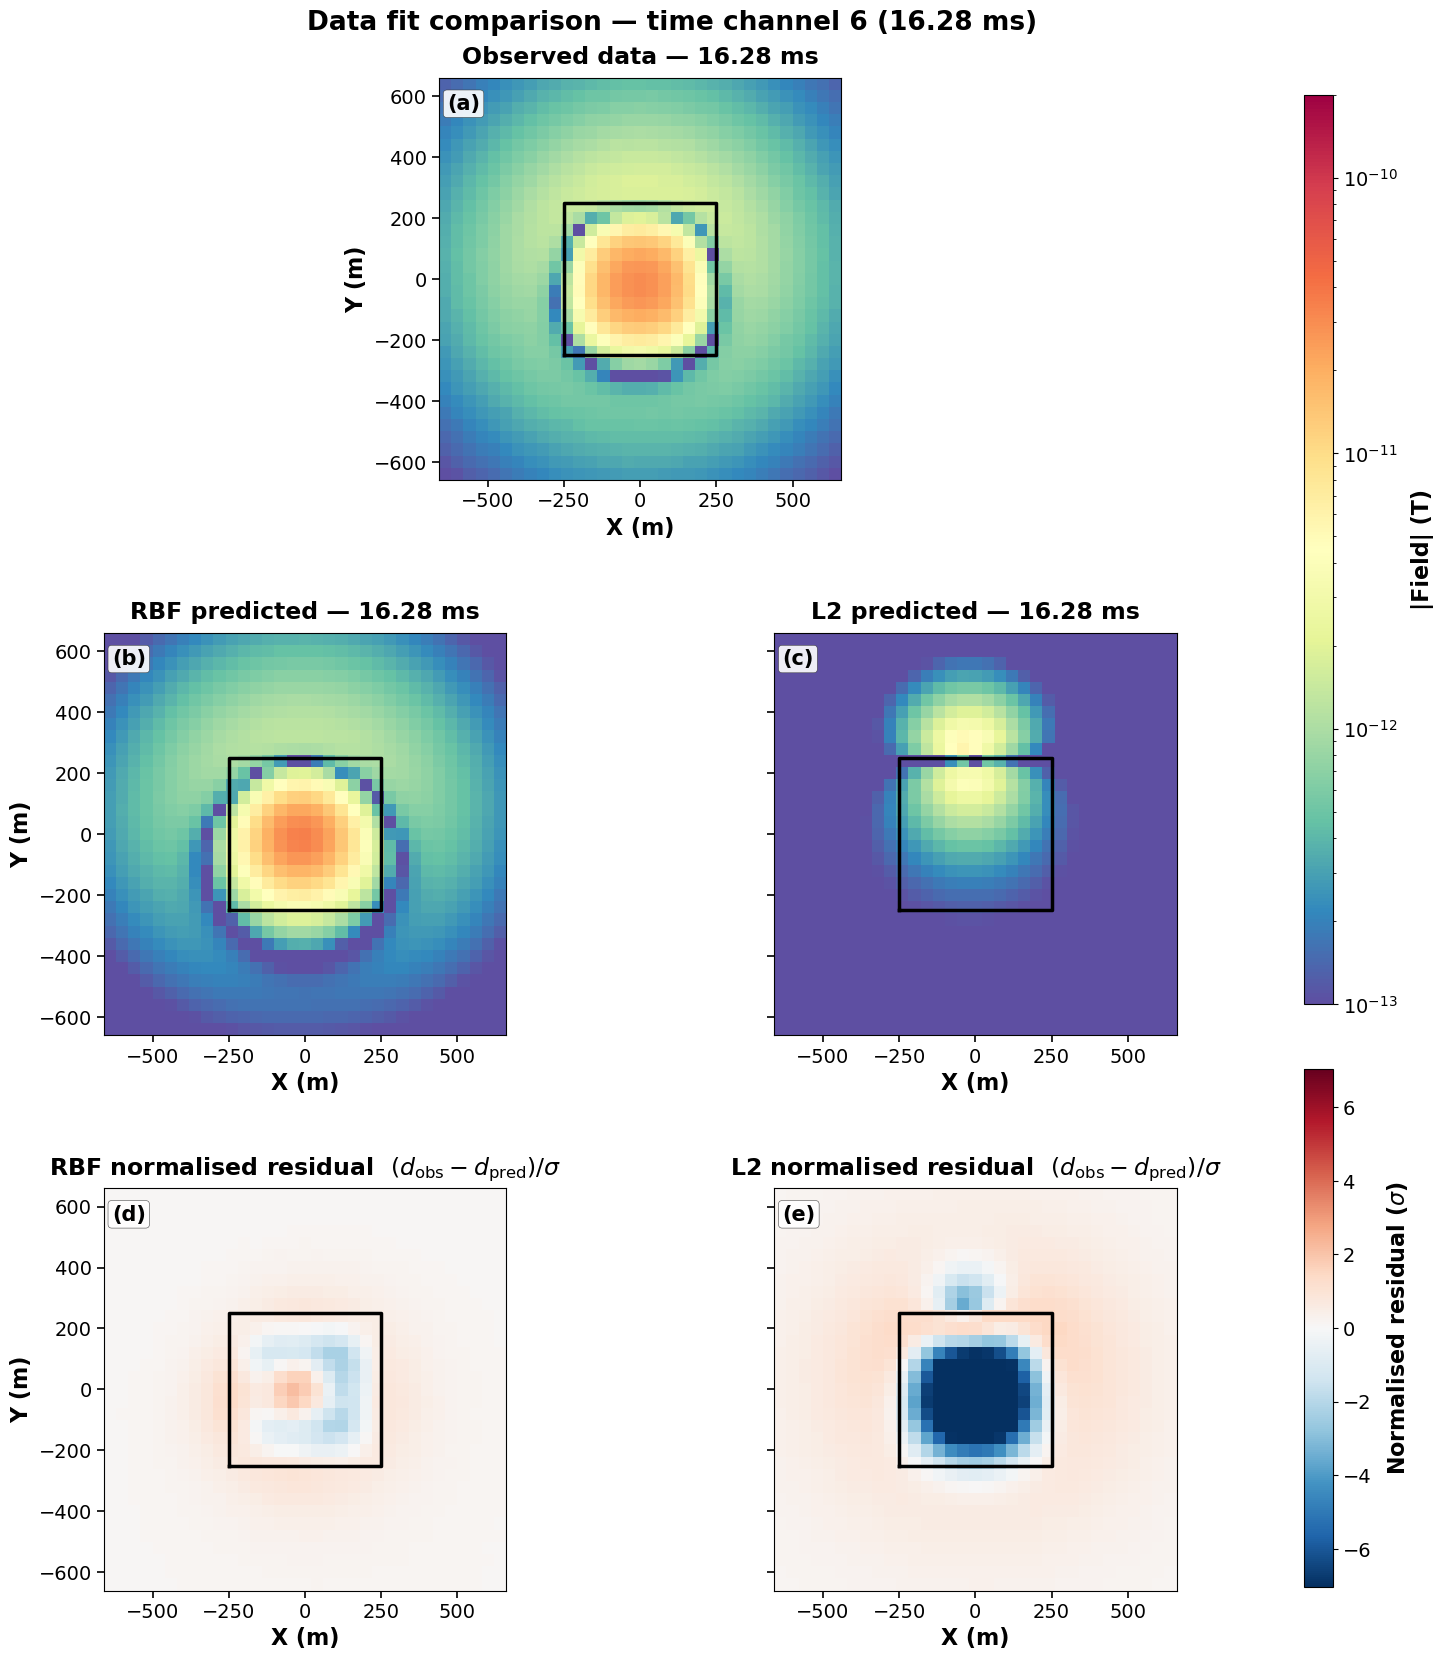

RMS normalised residual — RBF: 0.881   L2: 2.393
(target ≈ 1.0 at chi-factor = 1)


In [131]:
from matplotlib.ticker import LogFormatterMathtext, LogLocator
from matplotlib.gridspec import GridSpec

dpred_rbf = sim_param.dpred(mrec_rbf)
dpred_l2  = sim_nonparam.dpred(mrec_l2)

resid_rbf = (dobs - dpred_rbf) / uncertainty
resid_l2  = (dobs - dpred_l2)  / uncertainty

x_unique = np.unique(rx_locs[:, 0])
y_unique = np.unique(rx_locs[:, 1])
x_idx    = np.searchsorted(x_unique, rx_locs[:, 0])
y_idx    = np.searchsorted(y_unique, rx_locs[:, 1])
x_edges  = _centers_to_edges(x_unique)
y_edges  = _centers_to_edges(y_unique)

def _to_grid(vec):
    g = np.full((y_unique.size, x_unique.size), np.nan)
    g[y_idx, x_idx] = vec
    return g

def _at_t(vec, tidx):
    return vec.reshape((n_locations, n_times_used), order="F")[:, tidx]

tx_x = np.append(tx_locs[:, 0], tx_locs[0, 0])
tx_y = np.append(tx_locs[:, 1], tx_locs[0, 1])

t_idx  = 5
t_show = time_channels[t_idx] * 1e3

dobs_t     = np.abs(_at_t(dobs,      t_idx))
pred_rbf_t = np.abs(_at_t(dpred_rbf, t_idx))
pred_l2_t  = np.abs(_at_t(dpred_l2,  t_idx))
res_rbf_t  = _at_t(resid_rbf, t_idx)
res_l2_t   = _at_t(resid_l2,  t_idx)

vmin_d, vmax_d = 1e-13, 2e-10
data_norm = LogNorm(vmin=vmin_d, vmax=vmax_d)
res_lim   = max(np.percentile(np.abs(np.r_[res_rbf_t, res_l2_t]), 98), 3.0)
res_norm  = plt.Normalize(vmin=-res_lim, vmax=res_lim)

fig = plt.figure(figsize=(16, 17))
gs  = GridSpec(
    3, 2,
    figure=fig,
    height_ratios=[1.0, 1.0, 1.0],   # observed / predicted / residual
    hspace=0.38,
    wspace=0.10,
    left=0.08, right=0.88, top=0.94, bottom=0.05,
)

ax_obs = fig.add_subplot(gs[0, :])
ax_rbf_pred = fig.add_subplot(gs[1, 0])
ax_l2_pred  = fig.add_subplot(gs[1, 1])
ax_rbf_res  = fig.add_subplot(gs[2, 0])
ax_l2_res   = fig.add_subplot(gs[2, 1])

panel_font  = dict(fontsize=15, fontweight="bold")
title_font  = dict(fontsize=17, fontweight="bold", pad=10)
label_font  = dict(fontsize=16, fontweight="bold")
tick_kw     = dict(labelsize=14, width=1.2, length=5)
bbox_kw     = dict(boxstyle="round,pad=0.18", fc="white", ec="0.2", lw=0.4, alpha=0.9)

def _add_panel(ax, label, title, grid_data, norm, cmap, show_ylabel=True):
    pcm = ax.pcolormesh(x_edges, y_edges, grid_data,
                        cmap=cmap, norm=norm, shading="auto")
    ax.plot(tx_x, tx_y, color="k", lw=2.5, zorder=6)
    ax.set_title(title, **title_font)
    ax.text(0.02, 0.96, label, transform=ax.transAxes,
            va="top", ha="left", bbox=bbox_kw, **panel_font)
    ax.set_aspect("equal")
    ax.set_xlabel("X (m)", **label_font)
    ax.set_ylabel("Y (m)" if show_ylabel else "", **label_font)
    ax.tick_params(axis="both", **tick_kw)
    return pcm

pcm_data = _add_panel(
    ax_obs, "(a)",
    f"Observed data — {t_show:.2f} ms",
    _to_grid(np.clip(dobs_t, vmin_d, None)),
    data_norm, "Spectral_r",
)

_add_panel(
    ax_rbf_pred, "(b)",
    f"RBF predicted — {t_show:.2f} ms",
    _to_grid(np.clip(pred_rbf_t, vmin_d, None)),
    data_norm, "Spectral_r",
)

_add_panel(
    ax_l2_pred, "(c)",
    f"L2 predicted — {t_show:.2f} ms",
    _to_grid(np.clip(pred_l2_t, vmin_d, None)),
    data_norm, "Spectral_r",
    show_ylabel=False,
)
ax_l2_pred.set_yticklabels([])

pcm_res = _add_panel(
    ax_rbf_res, "(d)",
    r"RBF normalised residual  $(d_\mathrm{obs}-d_\mathrm{pred})/\sigma$",
    _to_grid(res_rbf_t),
    res_norm, "RdBu_r",
)

_add_panel(
    ax_l2_res, "(e)",
    r"L2 normalised residual  $(d_\mathrm{obs}-d_\mathrm{pred})/\sigma$",
    _to_grid(res_l2_t),
    res_norm, "RdBu_r",
    show_ylabel=False,
)
ax_l2_res.set_yticklabels([])

cbar_ax1 = fig.add_axes([0.895, 0.395, 0.018, 0.535])
cbar1 = fig.colorbar(pcm_data, cax=cbar_ax1)
cbar1.set_label("|Field| (T)", fontsize=16, fontweight="bold", labelpad=10)
cbar1.locator   = LogLocator(base=10.0)
cbar1.formatter = LogFormatterMathtext(base=10.0)
cbar1.update_ticks()
cbar1.ax.tick_params(labelsize=14)

cbar_ax2 = fig.add_axes([0.895, 0.052, 0.018, 0.305])
cbar2 = fig.colorbar(pcm_res, cax=cbar_ax2)
cbar2.set_label(r"Normalised residual ($\sigma$)", fontsize=16,
                fontweight="bold", labelpad=10)
cbar2.ax.tick_params(labelsize=14)

fig.suptitle(
    f"Data fit comparison — time channel {t_idx + 1} ({t_show:.2f} ms)",
    fontsize=19, fontweight="bold", y=0.98,
)
plt.savefig("data_fit_residual.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"RMS normalised residual — RBF: {np.sqrt(np.mean(resid_rbf**2)):.3f}   "
      f"L2: {np.sqrt(np.mean(resid_l2**2)):.3f}")
print("(target ≈ 1.0 at chi-factor = 1)")
